# 1L  Lab: DC Circuits
Auther: Darius Gichuru 

Course: PHYS485

Section: 0102

In [6]:
import sys, os
sys.path.append(os.path.abspath(".."))

import format
from format import *

import os
print(os.getcwd())
print(sys.executable)

/Users/darius/Desktop/School/fall2026/fall-2026-courses/phys485/lab1
/opt/anaconda3/bin/python


## 1L.1   Ohm's law

### Textbook questions
- No questions found in the textbook, rather general lab advice.

### Lecture questions
1. What does it mean to "verify" Ohm's law? (Remembering that we are not doing any error analysis in this course.) What measurements/graphs would nicely show this relation? What are the key aspects that "verify" it?
   - To verify ohm's law since it is a linear relation, I think it is best take a measurement of voltage across a resistor at varied current values. 
   - A graph showing voltage vs current as $V(I) = I R$ would nicely show this relation
   - Key aspects I can think of are, linear relations(i.e.,  a steady increase in voltage as current increases), small fractional devations 
2. Assuming your resistors are 1/8-watt resistors with a value of 15kΩ, what is the maximum voltage you can use?
3. What is the current limit on your ammeter? (Look at the input — it's on the label.) What does this imply about what values of voltage to use for a 15kΩ resistor?
4. Most scientists want both a table and a graph as part of their evidence. What graph should you make?
5. How many data points should you take? Why did you choose that many?
6. **Never use the voltage shown on the power supply screen — always measure with the multimeter at your circuit.** Why?
7. Volt/ohmmeters vs. ammeters: which goes in parallel with what you want to measure? Which goes in series? Why?

### Components
- Breadboard
- Jumper wires
- 15kOhm resistor (1/8 watt)

### Instructions
- Design a circuit to verify Ohm's law for a resistor using the power supply, two multimeters, and a resistor.

### Circuit diagrams
<p align="left">
  <img src="lab1_circuit1.png" alt="Circuit 1 Diagram" width="340" height="308"><br>
  <b>Circuit 1</b>
</p>

In [22]:
R_nominal = 14.71 * k          # 15 kΩ, using the k prefix from format.py
P_max = 1/8                 # watts, 1/8-watt resistor rating

# --- power-limited max voltage ---
V_max_power = np.sqrt(P_max * R_nominal)
print(f"Max voltage from power rating: {V_max_power:.1f} V")

# --- ammeter-limited max voltage ---
# Fill in AMMETER_I_MAX from your DMM's current-input label (in Amps)
AMMETER_I_MAX = None        # e.g. 0.2 for a 200 mA input — CHECK YOUR METER
if AMMETER_I_MAX:
    V_max_ammeter = AMMETER_I_MAX * R_nominal
    print(f"Max voltage from ammeter current limit: {V_max_ammeter:.1f} V")
    V_MAX = min(V_max_power, V_max_ammeter)
else:
    V_MAX = V_max_power

print(f"\nUse V_MAX = {V_MAX:.1f} V as your safe ceiling (also cap at your supply's max output).")

Max voltage from power rating: 42.9 V

Use V_MAX = 42.9 V as your safe ceiling (also cap at your supply's max output).


In [23]:
NUM_POINTS = 7   # answers lecture Q5 — adjust as you see fit, but justify it in your notebook

V_set = np.linspace(0, V_MAX, NUM_POINTS)   # your target supply settings

# Fill these in as you measure at your bench — DO NOT use the supply's screen value (lecture Q6)
V_measured = np.array([1.264, 2.551, 4.306, 5.838, 7.25, 8.11, 10.77, 12.14])   # multimeter reading across the resistor, one per point
I_measured = 10**(-3) * np.array([0.10, 0.19, 0.31, 0.41, 0.51, 0.57, 0.75, 0.84])   # ammeter reading in series, one per point

Measured R (from fit slope): 14682.3 Ω
Nominal R: 14710 Ω
Difference: 0.19%


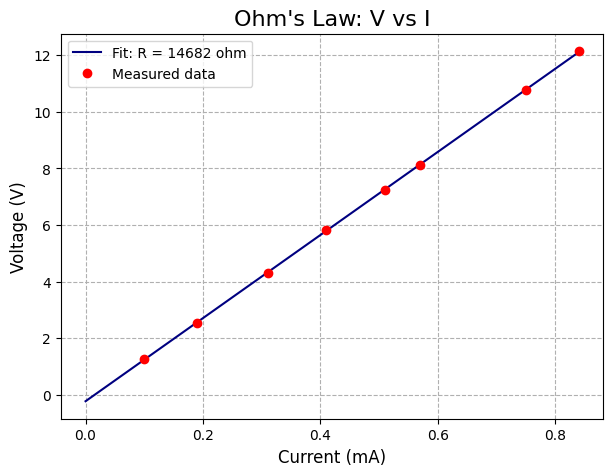

In [24]:
# Linear regression: V = I*R  ->  slope = R
fit = linregress(I_measured, V_measured)
R_fit = fit.slope

print(f"Measured R (from fit slope): {R_fit:.1f} Ω")
print(f"Nominal R: {R_nominal:.0f} Ω")
print(f"Difference: {abs(R_fit - R_nominal)/R_nominal*100:.2f}%")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(I_fit_line * 1000, fit.slope * I_fit_line + fit.intercept, '-', label=f'Fit: R = {R_fit:.0f} ohm', color = "navy")
ax.plot(I_measured * 1000, V_measured, 'o', label='Measured data', color = "red")
I_fit_line = np.linspace(0, I_measured.max(), 50) if len(I_measured) else np.array([0, 1])

# ax.axhline(y = V_MAX, color = "red", label = "Max voltage")
look_nice(ax, "Current (mA)", "Voltage (V)", "Ohm's Law: V vs I")
plt.show()

### Final Observations
- Relation is linear and thus we confirm ohm's law is true/vaild

## 1L.3   Voltage divider

### Textbook questions
- No questions found in the textbook, rather general lab advice.

### Lecture questions
1. When doing this experiment, should you use the nominal or measured values of the resistance? Why?
2. Discuss the text at the top of page 30 (shown below) with your instructor before wiring it.

### Instructions
1. Construct the voltage divider (Circuit 2): R1 = 15k, R2 = 15k, $V_{in} = 15V$.
2. Measure the **open-circuit** output voltage → record as $V_{output}$.
   - Expected: $V_{output} = V_{in} \cdot \frac{R_2}{R_1+R_2} \approx 7.5\text{V}$
---
3. Attach the 7.5k load (Circuit 3) and observe/record the loaded output voltage.
4. Measure the **short-circuit current**: short the output to ground, routing the current *through the ammeter* (don't bypass it) → record as $I_{short\ circuit}$.
   - Expected: $I_{sc} = \frac{V_{in}}{R_1} \approx 1\text{mA}$
   - Check the DVM's ammeter current range before shorting — avoid tripping the internal fuse.
---
5. Calculate the Thevenin equivalent:
   - $R_{Thev} = \dfrac{V_{output}}{I_{short\ circuit}}$
   - Expected: $R_{Thev} \approx 7.5\text{k}\Omega$ (matches $R_1 \parallel R_2$)
---
6. Build the Thevenin equivalent circuit (7.5V source + 7.5kΩ series resistor) and reattach the 7.5k load — confirm it reproduces the loaded output voltage from step 3.

### Circuit diagrams
<p align="left">
  <img src="lab1_circuit2.png" alt="Circuit 2 Diagram" width="340" height="308"><br>
  <b>Circuit 2</b>
</p>
<p align="left">
  <img src="lab1_circuit3.png" alt="Circuit 3 Diagram" width="340" height="308"><br>
  <b>Circuit 3</b>
</p>

In [57]:
Vin = 14.9            # V
R1 = 14.91 * k
R2 = 14.56 * k
Rload = 7.55 * k

# --- Expected open-circuit output (Circuit 2) ---
V_output_expected = Vin * R2 / (R1 + R2)
print(f"Expected V_output (open circuit): {V_output_expected:.2f} V")

# --- Expected loaded output (Circuit 3) ---
R2_parallel_load = (R2 * Rload) / (R2 + Rload)
V_output_loaded_expected = Vin * R2_parallel_load / (R1 + R2_parallel_load)
print(f"Expected V_output (with 7.5k load): {V_output_loaded_expected:.2f} V")

# --- Expected short-circuit current ---
I_sc_expected = Vin / R1
print(f"Expected I_short_circuit: {I_sc_expected*1000:.2f} mA")

# --- Expected Thevenin equivalent ---
R_Thev_expected = (R1 * R2) / (R1 + R2)
print(f"Expected R_Thev: {R_Thev_expected:.0f} ohm")

Expected V_output (open circuit): 7.36 V
Expected V_output (with 7.5k load): 3.73 V
Expected I_short_circuit: 1.00 mA
Expected R_Thev: 7366 ohm


In [78]:
V_output = 7.44          # measured open-circuit output voltage
V_output_loaded = 3.773   # measured output voltage with 7.5k load attached
I_short_circuit = 0.51 *10**(-3)  # measured short-circuit current (through ammeter, in Amps)

In [79]:
R_Thev = V_output / I_short_circuit
V_Thev = V_output   # open-circuit voltage IS the Thevenin voltage

print(f"Calculated R_Thev: {R_Thev/2:.0f} ohm  (expected ≈ {R_Thev_expected:.0f} ohm)")
print(f"Calculated V_Thev: {V_Thev:.2f} V")

Calculated R_Thev: 7294 ohm  (expected ≈ 7366 ohm)
Calculated V_Thev: 7.44 V


In [60]:
# Predict the loaded output using Thevenin values
V_load_from_Thev = V_Thev * Rload / (R_Thev + Rload)
print(f"Predicted loaded V_out from Thevenin model: {V_load_from_Thev:.2f} V")
print(f"Measured loaded V_out on original divider:  {V_output_loaded:.2f} V")
print(f"Difference: {abs(V_load_from_Thev - V_output_loaded):.3f} V")

Predicted loaded V_out from Thevenin model: 3.78 V
Measured loaded V_out on original divider:  3.76 V
Difference: 0.022 V


In [84]:



# second circuit
V_output = 7.44          # measured open-circuit output voltage
V_output_loaded = 3.773   # measured output voltage with 7.5k load attached
I_short_circuit = 0.51  # mA

# measured V_TH using the equalivalent thevenin circuit
V_Thev_meas = 3.722 # V
I_load_meas = 0.52 # mA
diff = V_load_from_Thev - V_Thev_meas


print(f"Measured loaded V_out from Thevenin circuit: {V_Thev_meas:.2f} V")
print(f"Predicted loaded V_out from Thevenin model: {V_load_from_Thev:.2f} V")
print(f"Difference: {diff:.3f} V")
print(f"Current throught the load: {I_load_meas:.3f} mA")

print("\n")
print(f"Voltage divider output voltage: {V_output_loaded} V")
print(f"Voltage divider short ccircuit current: {I_short_circuit} V")

Measured loaded V_out from Thevenin circuit: 3.72 V
Predicted loaded V_out from Thevenin model: 3.78 V
Difference: 0.057 V
Current throught the load: 0.520 mA


Voltage divider output voltage: 3.773 V
Voltage divider short ccircuit current: 0.51 V


Quantity                Expected    Measured
--------------------  ----------  ----------
V_output (open)             7.36        7.42
V_output (loaded)           3.73        3.76
I_short_circuit (mA)        1.00        1.02
R_Thev (ohm)             7366.46     7274.51


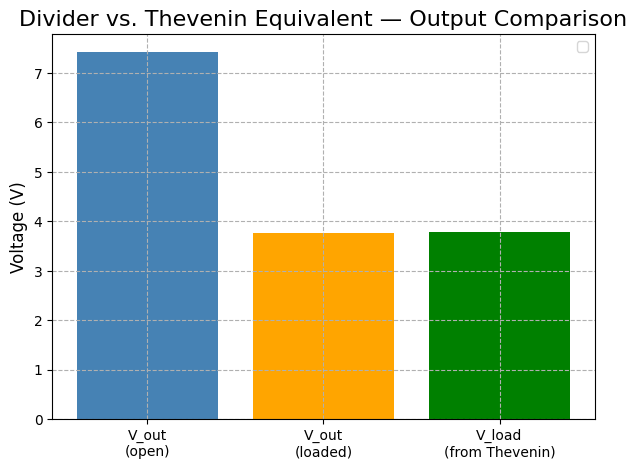

In [74]:
summary = {
    "Quantity": ["V_output (open)", "V_output (loaded)", "I_short_circuit (mA)", "R_Thev (ohm)"],
    "Expected": [V_output_expected, V_output_loaded_expected, I_sc_expected*1000, R_Thev_expected],
    "Measured": [V_output, V_output_loaded, (I_short_circuit or 0)*1000, R_Thev],
}
print(tb(summary, headers="keys", floatfmt=".2f"))

fig, ax = plt.subplots(figsize=(7, 5))
labels = ["V_out\n(open)", "V_out\n(loaded)", "V_load\n(from Thevenin)"]
values = [V_output, V_output_loaded, V_load_from_Thev]
ax.bar(labels, values, color=["steelblue", "orange", "green"])
look_nice(ax, "", "Voltage (V)", "Divider vs. Thevenin Equivalent — Output Comparison")
plt.show()